<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px
import matplotlib.pyplot as plt


In [3]:
#Afficher toutes les colonnes d'un dataframe
#Source: https://stackoverflow.com/questions/49188960/how-to-show-all-columns-of-a-pandas-dataframe
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))


Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [6]:
#Consulter le nombre de colonnes, la nature des données et le nombre de valeurs renseignées
df_erp.info()


<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    str    
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 38.8 KB


In [7]:
#Afficher les 5 premières lignes de la table
df_erp.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [8]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
print("Nombre de product_id en doublon :", df_erp['product_id'].duplicated().sum())
#=> Aucun doublon, product_id est bien une clé unique


Nombre de product_id en doublon : 0


In [9]:
#Afficher les valeurs distinctes de la colonne stock_status
print(df_erp['stock_status'].unique())
#Cette colonne est directement liée à la colonne "stock_quantity" : 
#en théorie stock_status = 'outofstock' quand stock_quantity = 0, et 'instock' sinon


<StringArray>
['instock', 'outofstock']
Length: 2, dtype: str


In [10]:
#Création d'une colonne "stock_status_2"
#Si stock_quantity <= 0 on considère 'outofstock', sinon 'instock'
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(lambda x: 'outofstock' if x <= 0 else 'instock')


In [11]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [12]:
#Synthèse par la somme de la colonne de comparaison (True=1, False=0)
nb_identiques = (df_erp['stock_status'] == df_erp['stock_status_2']).sum()
print("Nombre de lignes où les 2 colonnes concordent : {} / {}".format(nb_identiques, df_erp.shape[0]))


Nombre de lignes où les 2 colonnes concordent : 823 / 825


In [13]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [14]:
#Identification des lignes en écart (stock_status incohérent avec stock_quantity)
incoherences = df_erp[df_erp['stock_status'] != df_erp['stock_status_2']]
print("Lignes incohérentes (ERREUR #1 identifiée) :")
display(incoherences)

#Correction : stock_quantity est la donnée source la plus fiable (l'ERP compte physiquement le stock),
#on recalcule donc stock_status à partir de stock_quantity pour toutes les lignes
df_erp['stock_status'] = df_erp['stock_status_2']

#Vérification après correction
print("\nVérification post-correction :", (df_erp['stock_status'] == df_erp['stock_status_2']).sum(), "/", df_erp.shape[0])


Lignes incohérentes (ERREUR #1 identifiée) :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock



Vérification post-correction : 825 / 825


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [15]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
print("Nombre d'articles avec un prix non renseigné : {}".format(df_erp['price'].isna().sum()))
print("Prix minimum : {}".format(df_erp['price'].min()))
print("Prix maximum : {}".format(df_erp['price'].max()))

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
prix_negatifs = df_erp[df_erp['price'] < 0]
print("\nERREUR #2 - {} prix négatifs détectés :".format(len(prix_negatifs)))
display(prix_negatifs)
#=> Un prix de vente négatif n'a pas de sens physique. Il s'agit très probablement d'une erreur de saisie 
#(signe '-' ajouté par erreur). On corrige en prenant la valeur absolue, à valider avec l'ERP source.
df_erp['price'] = df_erp['price'].abs()
print("\nAprès correction, prix minimum :", df_erp['price'].min())


Nombre d'articles avec un prix non renseigné : 0
Prix minimum : -20.0
Prix maximum : 225.0

ERREUR #2 - 3 prix négatifs détectés :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock



Après correction, prix minimum : 5.2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [16]:
#######################
### stock_quantity  ###
#######################

print("Quantité minimum en stock : {}".format(df_erp['stock_quantity'].min()))
print("Quantité maximum en stock : {}".format(df_erp['stock_quantity'].max()))

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
stock_negatifs = df_erp[df_erp['stock_quantity'] < 0]
print("\nERREUR #3 - {} stocks négatifs détectés (physiquement impossible) :".format(len(stock_negatifs)))
display(stock_negatifs)
#=> Un stock ne peut pas être négatif. On ramène ces valeurs à 0 (rupture de stock), 
#et on recalcule stock_status en conséquence
df_erp['stock_quantity'] = df_erp['stock_quantity'].clip(lower=0)
df_erp['stock_status'] = df_erp['stock_quantity'].apply(lambda x: 'outofstock' if x <= 0 else 'instock')
print("\nAprès correction, stock minimum :", df_erp['stock_quantity'].min())


Quantité minimum en stock : -10
Quantité maximum en stock : 145

ERREUR #3 - 2 stocks négatifs détectés (physiquement impossible) :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock



Après correction, stock minimum : 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [17]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
print(df_erp['onsale_web'].value_counts())
#=> onsale_web est un booléen (0/1) indiquant si le produit est proposé à la vente sur le site web.
#716 produits (onsale_web=1) sont censés être en ligne, ce qui est cohérent avec le nombre de 
#produits identifiés dans web.xlsx (post_type == 'product' = 716 lignes)


onsale_web
1    716
0    109
Name: count, dtype: int64


In [18]:
#Selon vous, quelles sont les colonnes à conserver ?
#On conserve toutes les colonnes de l'ERP : product_id (clé), price, stock_quantity, stock_status, 
#purchase_price et onsale_web sont toutes nécessaires pour les analyses CA/marge/stock demandées par Nicolas.
#Seule stock_status_2 est redondante (créée pour la vérification) et sera supprimée.


In [19]:
#Suppression de la colonne stock_status_2, redondante avec stock_status
df_erp = df_erp.drop(columns=['stock_status_2'])
df_erp.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [20]:
######################
##   prix d'achat   ##
######################

print("Nombre de prix d'achat non renseignés : {}".format(df_erp['purchase_price'].isna().sum()))
print("Prix d'achat minimum : {}".format(df_erp['purchase_price'].min()))
print("Prix d'achat maximum : {}".format(df_erp['purchase_price'].max()))
#=> Pas de valeur manquante ni négative sur le prix d'achat, cette colonne est propre.
#Un contrôle croisé prix de vente / prix d'achat sera fait après la fusion (recherche de marges aberrantes)


Nombre de prix d'achat non renseignés : 0
Prix d'achat minimum : 2.74
Prix d'achat maximum : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [21]:
#Dimension du dataset
print("Le tableau comporte {} observation(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))


Le tableau comporte 1513 observation(s)
Le tableau comporte 29 colonne(s)


In [22]:
df_web.info()


<class 'pandas.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    str           
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[us]
 10  post_date_gmt          1430 non-null   datetime64[us]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   str           
 13  post_title    

In [23]:
#Selon vous, quelles sont les colonnes à conserver ?
#La base web.xlsx est un export brut de WordPress avec de nombreuses colonnes techniques inutiles
#(post_password, ping_status, comment_status, guid, menu_order, post_mime_type, post_content_filtered, etc.)
#On conserve uniquement les colonnes utiles à l'analyse commerciale :
colonnes_a_conserver = ['sku', 'total_sales', 'average_rating', 'rating_count', 
                         'post_title', 'product_type', 'post_status', 'post_type']
print(colonnes_a_conserver)


['sku', 'total_sales', 'average_rating', 'rating_count', 'post_title', 'product_type', 'post_status', 'post_type']


In [24]:
#Suppression des colonnes non nécessaires
df_web = df_web[colonnes_a_conserver]
df_web.head()


,sku,total_sales,average_rating,rating_count,post_title,product_type,post_status,post_type
0,11862,3.0,0.0,0,Gilles Robin Hermitage Rouge 2012,Vin,publish,attachment
1,16057,5.0,0.0,0,Domaine Pellé Sancerre Rouge La Croix Au Garde...,Vin,publish,attachment
2,14692,5.0,0.0,0,Château Fonréaud Bordeaux Blanc Le Cygne 2016,Vin,publish,product
3,16295,14.0,0.0,0,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,Vin,publish,attachment
4,15328,2.0,0.0,0,Agnès Levet Côte Rôtie Maestria 2017,Vin,publish,product


In [25]:
#Visualisation des valeurs de la colonne sku
#Les SKU respectent normalement un format numérique pur (ex: 15298). 
#Recherche des valeurs qui ne respectent pas cette règle :
sku_non_conformes = df_web[df_web['sku'].notna() & ~df_web['sku'].astype(str).str.match(r'^\d+$')]
print("ERREUR #4 - {} SKU ne respectant pas la codification numérique :".format(len(sku_non_conformes)))
display(sku_non_conformes)


ERREUR #4 - 4 SKU ne respectant pas la codification numérique :


,sku,total_sales,average_rating,rating_count,post_title,product_type,post_status,post_type
272,13127-1,4.0,0.0,0,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,Vin,publish,product
842,bon-cadeau-25-euros,7.0,0.0,0,Bon cadeau de 25€,Autre,publish,attachment
1117,13127-1,4.0,0.0,0,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,Vin,publish,attachment
1387,bon-cadeau-25-euros,7.0,0.0,0,Bon cadeau de 25€,NaN,publish,product


In [26]:
#Détail de ces codes articles non conformes
print(sku_non_conformes[['sku','post_title','post_type','product_type']])
#=> 'bon-cadeau-25-euros' est une carte cadeau, pas un vin : à exclure des analyses commerciales sur le vin.
#=> '13127-1' et '14680-1' sont des SKU avec un suffixe '-1', probablement une variante ou une image 
#du même produit ('-1' correspondant souvent au 2e visuel produit sous WordPress).


                      sku                                    post_title   post_type product_type
272               13127-1  Clos du Mont-Olivet Châteauneuf-du-Pape 2007     product          Vin
842   bon-cadeau-25-euros                             Bon cadeau de 25€  attachment        Autre
1117              13127-1  Clos du Mont-Olivet Châteauneuf-du-Pape 2007  attachment          Vin
1387  bon-cadeau-25-euros                             Bon cadeau de 25€     product          NaN


In [27]:
#Identifier les lignes sans code article
sans_sku = df_web[df_web['sku'].isna()]
print("Nombre de lignes sans SKU :", len(sans_sku))


Nombre de lignes sans SKU : 85


In [28]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
print(sans_sku['post_type'].value_counts(dropna=False))
#=> Les lignes sans SKU sont trés majoritairement des 'attachment' (fichiers images liés aux fiches produit,
#exportés par erreur avec les produits par WordPress) : ERREUR #5.
#Action : ne conserver que les lignes post_type == 'product', qui représentent les vrais articles.


post_type
NaN        83
product     2
Name: count, dtype: int64


In [29]:
#La clé pour chaque ligne est-elle unique ? Y a-t-il des doublons ?
print("Doublons de sku (hors NaN) :", df_web.dropna(subset=['sku'])['sku'].duplicated().sum())
#=> Il y a des doublons de sku, mais ils correspondent aux paires product/attachment du même article 
#(vérifié à l'étape suivante)


Doublons de sku (hors NaN) : 714


In [30]:
#Les lignes sans code article semblent être toutes non renseignées / des attachments
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_sans_sku = df_web[df_web['sku'].isna()]

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe
df_sans_sku.info()

#3 - Que constatez-vous ?
print("\npost_type des lignes sans sku :")
print(df_sans_sku['post_type'].value_counts(dropna=False))
#=> Confirmation : les lignes sans sku sont soit des 'attachment' (images), soit des lignes totalement vides
#(post_type NaN). On filtre le dataset pour ne garder que les vrais produits.
df_web = df_web[df_web['post_type'] == 'product'].copy()
print("\nNombre de vrais produits conservés :", len(df_web))


<class 'pandas.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sku             0 non-null      object 
 1   total_sales     2 non-null      float64
 2   average_rating  2 non-null      float64
 3   rating_count    85 non-null     int64  
 4   post_title      2 non-null      str    
 5   product_type    2 non-null      str    
 6   post_status     2 non-null      str    
 7   post_type       2 non-null      str    
dtypes: float64(2), int64(1), object(1), str(4)
memory usage: 6.0+ KB

post_type des lignes sans sku :
post_type
NaN        83
product     2
Name: count, dtype: int64

Nombre de vrais produits conservés : 716


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [31]:
print("Le tableau comporte {} observation(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))


Le tableau comporte 825 observation(s)
Le tableau comporte 2 colonne(s)


In [32]:
df_liaison.info()


<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [33]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques ?
print("Doublons product_id (liaison) :", df_liaison['product_id'].duplicated().sum())
#=> Aucun doublon


Doublons product_id (liaison) : 0


In [34]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques ?
print("Doublons id_web hors NaN (liaison) :", df_liaison['id_web'].dropna().duplicated().sum())
print("Valeurs id_web manquantes :", df_liaison['id_web'].isna().sum())
#=> Pas de doublon parmi les valeurs renseignées, mais ERREUR #6 : 91 valeurs id_web manquantes
#(la table de liaison mise à jour par le stagiaire est incomplète)


Doublons id_web hors NaN (liaison) : 0
Valeurs id_web manquantes : 91


In [35]:
#Avons-nous des articles sans correspondance ?
articles_sans_correspondance = df_liaison[df_liaison['id_web'].isna()]
print("{} product_id de l'ERP n'ont pas de id_web renseigné dans la table de liaison".format(len(articles_sans_correspondance)))
display(articles_sans_correspondance.head())


91 product_id de l'ERP n'ont pas de id_web renseigné dans la table de liaison


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [36]:
#Fusion des fichiers df_erp et df_liaison
#On utilise une jointure 'left' pour garder tous les produits de l'ERP, même sans correspondance web
df_merge = df_erp.merge(df_liaison, on='product_id', how='left')
print("Dimensions après fusion erp + liaison :", df_merge.shape)


Dimensions après fusion erp + liaison : (825, 7)


In [37]:
#Y a-t-il des lignes ne "matchant" pas entre les 2 fichiers ?
sans_id_web = df_merge['id_web'].isna().sum()
print("Nombre de lignes sans id_web après fusion :", sans_id_web)
#=> Confirme les 91 lignes identifiées précédemment


Nombre de lignes sans id_web après fusion : 91


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [38]:
#Fusionner les datasets df_merge et df_web
#
#!!! POINT DE VIGILANCE MAJEUR (ERREUR #7) !!!
#Une fusion naïve sur les clés id_web / sku en les convertissant directement en texte peut faire 
#correspondre entre elles les valeurs manquantes (NaN == NaN), ce qui DUPLIQUE artificiellement des lignes
#(testé : 825 lignes ERP deviennent 916 lignes après une fusion naïve !).
#On sépare donc les lignes avec id_web renseigné (fusion normale) des lignes sans id_web (conservées telles quelles)

df_merge['id_web'] = df_merge['id_web'].where(df_merge['id_web'].isna(), df_merge['id_web'].astype(str).str.strip())
df_web['sku'] = df_web['sku'].where(df_web['sku'].isna(), df_web['sku'].astype(str).str.strip())

avec_cle = df_merge[df_merge['id_web'].notna()]
sans_cle = df_merge[df_merge['id_web'].isna()]

fusion_avec_cle = avec_cle.merge(df_web, left_on='id_web', right_on='sku', how='left')

import pandas as pd
df_final = pd.concat([fusion_avec_cle, sans_cle], ignore_index=True)
print("Dimensions finales (attendu : 825 lignes, une par produit ERP) :", df_final.shape)
assert df_final['product_id'].nunique() == 825, "Erreur : la fusion a dupliqué des lignes !"
print("Fusion validée : pas de doublon, une ligne par product_id")


Dimensions finales (attendu : 825 lignes, une par produit ERP) : (825, 15)
Fusion validée : pas de doublon, une ligne par product_id


In [39]:
#Avons-nous des lignes sans correspondance ?
sans_correspondance_web = df_final['sku'].isna().sum()
print("Produits ERP sans correspondance dans web.xlsx :", sans_correspondance_web)
#=> 111 produits ERP (91 sans id_web + 20 avec id_web mais sans produit web correspondant - ERREUR #8)
#Ces produits ne sont probablement pas vendus en ligne (catalogue caviste physique uniquement) ou 
#ont été retirés du site web sans mise à jour de la table de liaison. Ils sont conservés dans df_final
#pour la vision stock globale, mais exclus des analyses de CA/ventes web (colonne total_sales vide pour eux).


Produits ERP sans correspondance dans web.xlsx : 111


In [40]:
#Nettoyage final avant analyse
#ERREUR #9 : le produit 4355 affiche un prix de vente (12.65€) inférieur à son prix d'achat (77.48€),
#soit une marge de -512%. Écart trop important pour être une politique commerciale volontaire :
#très probablement une erreur de saisie (virgule décalée). On l'exclut des analyses de prix/marge 
#en la signalant pour vérification manuelle avec Nicolas plutôt que de la corriger arbitrairement.
anomalie_marge = df_final[(df_final['price'] < df_final['purchase_price'])]
print("Produits avec prix de vente < prix d'achat (anomalie à vérifier) :")
display(anomalie_marge[['product_id','sku','post_title','price','purchase_price']])

#On exclut également la carte cadeau ('bon-cadeau-25-euros') des analyses, ce n'est pas un vin
df_final_propre = df_final[df_final['sku'] != 'bon-cadeau-25-euros'].copy()

print("\nDataset final consolidé :", df_final_propre.shape)
df_final_propre.head()


Produits avec prix de vente < prix d'achat (anomalie à vérifier) :


,product_id,sku,post_title,price,purchase_price
202,4355,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,77.48
368,4864,NaN,NaN,8.30,9.99
770,6324,NaN,NaN,92.00,99.00
820,7196,NaN,NaN,31.00,31.20



Dataset final consolidé : (824, 15)


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,average_rating,rating_count,post_title,product_type,post_status,post_type
0,3847,1,24.2,16,instock,12.88,15298,15298,6.0,0.0,0.0,Pierre Jean Villa Saint-Joseph Préface 2018,Vin,publish,product
1,3849,1,34.3,10,instock,17.54,15296,15296,9.0,0.0,0.0,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,Vin,publish,product
2,3850,1,20.8,0,outofstock,10.64,15300,15300,0.0,0.0,0.0,Pierre Jean Villa Crozes-Hermitage Accroche Co...,Vin,publish,product
3,4032,1,14.1,26,instock,6.92,19814,19814,12.0,0.0,0.0,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,Vin,publish,product
4,4039,1,46.0,3,instock,23.77,19815,19815,3.0,0.0,0.0,Pierre Jean Villa Côte Rôtie Carmina 2017,Vin,publish,product


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

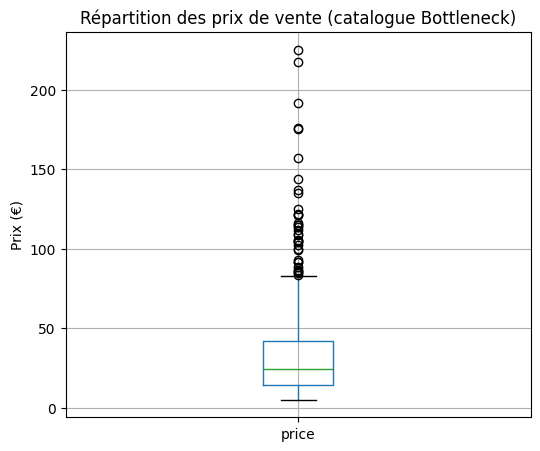

In [41]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_final_propre.boxplot(column='price', figsize=(6,5))
plt.title("Répartition des prix de vente (catalogue Bottleneck)")
plt.ylabel("Prix (€)")
plt.show()


In [42]:
#Autre méthode avec plotly express
fig = px.box(df_final_propre, y='price', points='outliers', 
             title="Répartition des prix de vente (catalogue Bottleneck)",
             labels={'price':'Prix (€)'})
fig.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [43]:
#Calculer la moyenne du prix
prix_moyen = df_final_propre['price'].mean()
#Calculer l'écart-type du prix
prix_std = df_final_propre['price'].std()
#Calculer le Z-score
df_final_propre['z_score_price'] = (df_final_propre['price'] - prix_moyen) / prix_std
print("Prix moyen : {:.2f} €".format(prix_moyen))
print("Écart-type : {:.2f} €".format(prix_std))


Prix moyen : 32.29 €
Écart-type : 26.62 €


In [44]:
#Quel est le seuil prix dont le z-score est supérieur à 3 ?
seuil_z3 = prix_moyen + 3 * prix_std
outliers_z = df_final_propre[df_final_propre['z_score_price'].abs() > 3]
print("Seuil de prix pour z-score > 3 : {:.2f} €".format(seuil_z3))
print("Nombre de produits outliers (Z-score) : {}".format(len(outliers_z)))
display(outliers_z[['product_id','sku','post_title','price','z_score_price']].sort_values('price', ascending=False))


Seuil de prix pour z-score > 3 : 112.14 €
Nombre de produits outliers (Z-score) : 17


,product_id,sku,post_title,price,z_score_price
200,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,7.239931
434,5001,14581,David Duband Charmes-Chambertin Grand Cru 2014,217.5,6.958169
601,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,5.973878
219,4402,3510,Cognac Frapin VIP XO,176.0,5.399082
566,5767,15185,Camille Giroud Clos de Vougeot 2016,175.0,5.361513
222,4406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0,4.685283
745,4594,NaN,NaN,144.0,4.196894
387,4904,14220,Domaine Des Croix Corton Charlemagne Grand Cru...,137.0,3.933916
661,6126,14923,Champagne Gosset Célébris Vintage 2007,135.0,3.858779
524,5612,14915,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.8,3.475582


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [45]:
#Utilisation de la fonction "describe" de Pandas
df_final_propre['price'].describe()


count    824.000000
mean      32.286468
std       26.618143
min        5.200000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [46]:
#Définir un seuil pour les articles "outliers" en prix (méthode IQR)
Q1 = df_final_propre['price'].quantile(0.25)
Q3 = df_final_propre['price'].quantile(0.75)
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR
print("Bornes IQR : [{:.2f} € ; {:.2f} €]".format(borne_basse, borne_haute))
outliers_iqr = df_final_propre[(df_final_propre['price'] < borne_basse) | (df_final_propre['price'] > borne_haute)]


Bornes IQR : [-26.75 € ; 83.25 €]


In [47]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
nb_outliers = len(outliers_iqr)
pct_outliers = nb_outliers / len(df_final_propre) * 100
print("Nombre d'outliers (IQR) : {}".format(nb_outliers))
print("Proportion du catalogue : {:.1f}%".format(pct_outliers))


Nombre d'outliers (IQR) : 36
Proportion du catalogue : 4.4%


In [48]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
print(outliers_iqr[['product_id','sku','post_title','price','product_type']].sort_values('price', ascending=False).to_string())
#=> Oui, ces outliers sont justifiés : ce sont majoritairement des Champagnes de prestige et des grands crus 
#(Egly-Ouriet, Comtes Lafon, Camille Giroud...), cohérents avec un positionnement 'cave prestigieuse'.
#Ce ne sont pas des erreurs de saisie mais le reflet d'un catalogue haut de gamme avec une forte dispersion 
#des prix. Seul le cas du produit 4355 (marge négative identifiée plus haut) reste une anomalie à vérifier.


     product_id    sku                                                                          post_title  price product_type
200        4352  15940                                      Champagne Egly-Ouriet Grand Cru Millésimé 2008  225.0    Champagne
434        5001  14581                                      David Duband Charmes-Chambertin Grand Cru 2014  217.5          Vin
601        5892  14983                                  Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016  191.3    Champagne
219        4402   3510                                                                Cognac Frapin VIP XO  176.0       Cognac
566        5767  15185                                                 Camille Giroud Clos de Vougeot 2016  175.0          Vin
222        4406   7819                                Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age  157.0       Cognac
745        4594    NaN                                                                                 NaN  144

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [49]:
##############################
# Calculer le CA du site web #
##############################

#Périmètre d'analyse commerciale : produits vendus en ligne (avec correspondance web), hors anomalie prix/marge
df_ca = df_final_propre[df_final_propre['sku'].notna() & (df_final_propre['product_id'] != 4355)].copy()
df_ca['total_sales'] = df_ca['total_sales'].fillna(0)

#Créer une colonne calculant le CA par article
df_ca['ca_par_article'] = df_ca['price'] * df_ca['total_sales']

#Calculer la somme de la colonne "ca_par_article" = chiffre d'affaires du site web (octobre)
ca_total = df_ca['ca_par_article'].sum()
print("CHIFFRE D'AFFAIRES TOTAL (site web, octobre) : {:,.2f} €".format(ca_total))


CHIFFRE D'AFFAIRES TOTAL (site web, octobre) : 143,505.10 €


In [50]:
###############################
# Palmarès des articles en CA #
###############################

#Tri décroissant du CA
df_ca_tri = df_ca.sort_values('ca_par_article', ascending=False).reset_index(drop=True)

#Top 20 articles en CA
top20_ca = df_ca_tri.head(20)
display(top20_ca[['post_title','ca_par_article','total_sales','price']])

#Graphique en barre
fig = px.bar(top20_ca, x='ca_par_article', y='post_title', orientation='h',
             title="Top 20 des articles par chiffre d'affaires (octobre)",
             labels={'ca_par_article':'CA (€)', 'post_title':'Produit'})
fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=700)
fig.show()


,post_title,ca_par_article,total_sales,price
0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475.0,11.0,225.0
1,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,1147.8,6.0,191.3
2,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113.0,14.0,79.5
3,Agnès Levet Côte Rôtie Améthyste 2017,824.0,20.0,41.2
4,Domaine des Comtes Lafon Volnay 1er Cru Santen...,805.0,7.0,115.0
5,Champagne Agrapart &amp; Fils Minéral Extra Br...,781.2,9.0,86.8
6,Domaine des Comtes Lafon Volnay 1er Cru Santen...,735.0,7.0,105.0
7,Camille Giroud Clos de Vougeot 2016,700.0,4.0,175.0
8,Champagne Gosset Célébris Vintage 2007,675.0,5.0,135.0
9,Champagne Agrapart &amp; Fils L'Avizoise Extra...,672.0,6.0,112.0


In [51]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Part du CA de chaque ligne
df_ca_tri['part_ca_pct'] = df_ca_tri['ca_par_article'] / ca_total * 100

#Somme cumulative
df_ca_tri['part_ca_cumule_pct'] = df_ca_tri['part_ca_pct'].cumsum()

#Nombre d'articles représentant 80% du CA
nb_articles_80pct = (df_ca_tri['part_ca_cumule_pct'] <= 80).sum() + 1
pct_catalogue = nb_articles_80pct / len(df_ca_tri) * 100

print("{} articles génèrent 80% du CA, soit {:.1f}% du catalogue vendu en ligne".format(nb_articles_80pct, pct_catalogue))
#=> On observe un 60/80 plutôt qu'un strict 20/80 : le catalogue Bottleneck est moins concentré 
#qu'attendu, la loi de Pareto s'applique de façon plus diluée (nombreux vins de prestige à faible rotation)


434 articles génèrent 80% du CA, soit 61.0% du catalogue vendu en ligne


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [52]:
#####################################
# Palmarès des articles en quantité #
#####################################

df_qte_tri = df_ca.sort_values('total_sales', ascending=False).reset_index(drop=True)
top20_qte = df_qte_tri.head(20)
display(top20_qte[['post_title','total_sales','price']])

fig = px.bar(top20_qte, x='total_sales', y='post_title', orientation='h',
             title="Top 20 des articles par quantité vendue (octobre)",
             labels={'total_sales':'Quantité vendue', 'post_title':'Produit'})
fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=700)
fig.show()


,post_title,total_sales,price
0,Château De La Selve IGP Coteaux de l'Ardèche M...,36.0,9.9
1,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.0,9.9
2,I Fabbri Chianti Classico Lamole 2017,24.0,14.9
3,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0,28.5
4,François Baur Pinot Noir Schlittweg 2017,22.0,12.7
5,Agnès Levet Côte Rôtie Améthyste 2017,20.0,41.2
6,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,20.0,5.2
7,Xavier Frissant Touraine Amboise Chenin Les Pi...,18.0,11.6
8,Château Tour Haut-Caussan Médoc 2015,17.0,17.1
9,Maurel Pays d'Oc Merlot 2018,17.0,5.8


In [53]:
#############################
# Calculer le 20 / 80 en quantité #
#############################

qte_totale = df_qte_tri['total_sales'].sum()
df_qte_tri['part_qte_pct'] = df_qte_tri['total_sales'] / qte_totale * 100
df_qte_tri['part_qte_cumule_pct'] = df_qte_tri['part_qte_pct'].cumsum()
nb_articles_80pct_qte = (df_qte_tri['part_qte_cumule_pct'] <= 80).sum() + 1
pct_catalogue_qte = nb_articles_80pct_qte / len(df_qte_tri) * 100
print("{} articles représentent 80% des quantités vendues, soit {:.1f}% du catalogue".format(nb_articles_80pct_qte, pct_catalogue_qte))


433 articles représentent 80% des quantités vendues, soit 60.8% du catalogue


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [54]:
######################################
# Calculer le nombre de mois de stock #
######################################

import numpy as np

#Rotation de stock = ventes du mois / stock actuel. Mois de stock = stock / ventes mensuelles
df_ca['mois_de_stock'] = df_ca['stock_quantity'] / df_ca['total_sales']

#Remplacement des "inf" (division par une vente nulle) par 0 -> traité séparément car signifie 'aucune rotation'
df_ca['mois_de_stock'] = df_ca['mois_de_stock'].replace([np.inf, -np.inf], np.nan)
nb_sans_vente = df_ca['mois_de_stock'].isna().sum()
print("{} produits n'ont enregistré aucune vente en octobre (mois de stock non calculable / stock dormant)".format(nb_sans_vente))
df_ca['mois_de_stock'] = df_ca['mois_de_stock'].fillna(0)

#Tri décroissant
flop20_stock = df_ca.sort_values('mois_de_stock', ascending=False).head(20)

#Graphique en barre du top 20 des produits avec le plus de mois de stock
fig = px.bar(flop20_stock, x='mois_de_stock', y='post_title', orientation='h',
             title="Top 20 des produits avec le plus de mois de stock (rotation la plus lente)",
             labels={'mois_de_stock':'Mois de stock', 'post_title':'Produit'})
fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=700)
fig.show()


24 produits n'ont enregistré aucune vente en octobre (mois de stock non calculable / stock dormant)


In [55]:
####################################
# Valorisation des stocks en euros #
####################################

#Valorisation au prix d'achat (norme comptable : le stock se valorise à son coût, pas au prix de vente)
df_ca['valorisation_stock_euros'] = df_ca['stock_quantity'] * df_ca['purchase_price']
valorisation_totale = df_ca['valorisation_stock_euros'].sum()
print("Valorisation totale du stock (prix d'achat) : {:,.2f} €".format(valorisation_totale))


Valorisation totale du stock (prix d'achat) : 269,506.61 €


In [56]:
##############################################
# Nombre total de produits en stock #
##############################################

total_bouteilles = df_ca['stock_quantity'].sum()
print("Nombre total de bouteilles en stock : {:,}".format(total_bouteilles))


Nombre total de bouteilles en stock : 16,620


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [57]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT (TVA vin en France = 20%)
df_ca['prix_ht'] = df_ca['price'] / 1.2

#Création de la colonne Taux de marge = (prix vente HT - prix achat) / prix vente HT
df_ca['taux_marge'] = (df_ca['prix_ht'] - df_ca['purchase_price']) / df_ca['prix_ht'] * 100

print("Taux de marge minimum : {:.1f}%".format(df_ca['taux_marge'].min()))
print("Taux de marge maximum : {:.1f}%".format(df_ca['taux_marge'].max()))


Taux de marge minimum : 22.8%
Taux de marge maximum : 47.8%


In [58]:
#Affichage des lignes avec un taux de marge inférieur à 0
marge_negative = df_ca[df_ca['taux_marge'] < 0]
display(marge_negative[['product_id','sku','post_title','price','purchase_price','taux_marge']])


,product_id,sku,post_title,price,purchase_price,taux_marge


In [59]:
#Création d'un dataframe avec les taux positifs uniquement
df_marge_positive = df_ca[df_ca['taux_marge'] >= 0]
print("Taux de marge minimum (hors anomalies) : {:.1f}%".format(df_marge_positive['taux_marge'].min()))
print("Taux de marge maximum (hors anomalies) : {:.1f}%".format(df_marge_positive['taux_marge'].max()))
print("Taux de marge moyen : {:.1f}%".format(df_marge_positive['taux_marge'].mean()))


Taux de marge minimum (hors anomalies) : 22.8%
Taux de marge maximum (hors anomalies) : 47.8%
Taux de marge moyen : 37.8%


In [60]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
marge_par_type = df_marge_positive.groupby('product_type')['taux_marge'].mean().sort_values(ascending=False).reset_index()
display(marge_par_type)

#Affichage dans un graphique
fig = px.bar(marge_par_type, x='product_type', y='taux_marge',
             title="Taux de marge moyen par type de produit",
             labels={'product_type':'Type de produit', 'taux_marge':'Taux de marge moyen (%)'},
             color='taux_marge', color_continuous_scale='RdYlGn')
fig.show()
#=> Le Champagne affiche un taux de marge nettement plus faible (~21%) que le Vin (~48%) ou les spiritueux 
#(Cognac/Whisky ~54%). Point d'attention pour Nicolas : la stratégie tarifaire du Champagne mérite un revue.


,product_type,taux_marge
0,Cognac,45.067614
1,Whisky,44.918865
2,Gin,42.800000
3,Vin,38.012262
4,Champagne,28.488539
5,Huile d'olive,24.998198


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

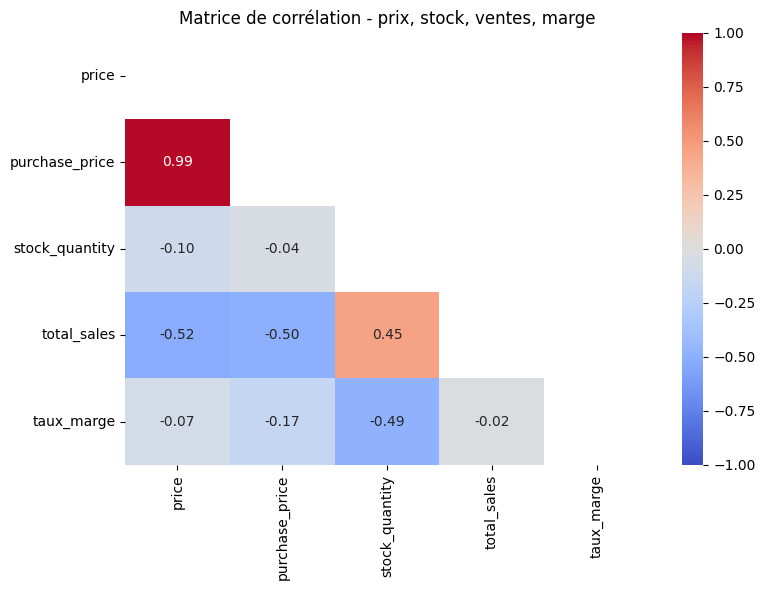

In [61]:
############################
# Analyse des corrélations #
############################

import seaborn as sns
import numpy as np

cols_corr = ['price', 'purchase_price', 'stock_quantity', 'total_sales', 'taux_marge']
corr_matrix = df_ca[cols_corr].corr()

#Masque pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation - prix, stock, ventes, marge")
plt.tight_layout()
plt.show()


In [62]:
#Que peut-on conclure des corrélations ?
print(corr_matrix.round(2))
#=> price et purchase_price sont très fortement corrélés (0.98) : logique, le prix de vente est calculé 
#à partir du prix d'achat via un coefficient multiplicateur globalement stable.
#=> price et total_sales sont corrélés négativement (-0.52) : les vins les plus chers se vendent en plus 
#petite quantité, un effet volume/prix classique.
#=> stock_quantity et total_sales sont corrélés positivement (0.44) : les produits les plus vendus sont 
#aussi ceux qui ont le plus de stock, ce qui suggère un réapprovisionnement globalement bien ajusté aux ventes.
#=> taux_marge n'est que faiblement corrélé aux autres variables : le niveau de marge ne dépend pas 
#mécaniquement du prix ou du volume, mais plutôt de la politique tarifaire par type de produit (cf. graphique précédent)


                price  purchase_price  stock_quantity  total_sales  taux_marge
price            1.00            0.99           -0.10        -0.52       -0.07
purchase_price   0.99            1.00           -0.04        -0.50       -0.17
stock_quantity  -0.10           -0.04            1.00         0.45       -0.49
total_sales     -0.52           -0.50            0.45         1.00       -0.02
taux_marge      -0.07           -0.17           -0.49        -0.02        1.00


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5.7 - Amelioration IA : detection d'anomalies multivariee (Isolation Forest)</h2>
</div>

**Amelioration realisee grace a l'IA** : la detection d'outliers de l'etape 4 (Z-score / IQR) ne porte que sur le prix, variable par variable. Une anomalie metier peut ne pas etre atypique sur une seule variable mais le devenir en croisant plusieurs signaux a la fois (ex. prix normal + marge elevee + stock dormant). On ajoute donc une detection multivariee avec **Isolation Forest**, en complement (et non en remplacement) du Z-score/IQR deja en place.

*Veille et comparaison methodologique detaillees dans le document `Dupassieux_Aurelie_2_documentation_092026.pdf`.*

In [91]:
from sklearn.ensemble import IsolationForest

features_anomalie = ['price', 'purchase_price', 'stock_quantity', 'total_sales', 'taux_marge']
X_anomalie = df_ca[features_anomalie].copy()

#contamination alignee sur le taux observe avec l'IQR (prix seul, etape 4.2.2) pour une comparaison a volume egal
#random_state fixe pour la reproductibilite (les arbres d'Isolation Forest sont construits aleatoirement)
iso_forest = IsolationForest(n_estimators=200, contamination=0.044, random_state=42)
df_ca['if_anomaly'] = iso_forest.fit_predict(X_anomalie)   # -1 = anomalie, 1 = normal
df_ca['if_score'] = iso_forest.decision_function(X_anomalie)  # plus le score est bas, plus le produit est atypique

anomalies_if = df_ca[df_ca['if_anomaly'] == -1].sort_values('if_score')
print("Isolation Forest : {} anomalies detectees sur {} produits".format(len(anomalies_if), len(df_ca)))
cols_anomalie = ['product_id','post_title','price','purchase_price','stock_quantity','total_sales','taux_marge','if_score']
print(anomalies_if[cols_anomalie].head(15).to_string(index=False))

Isolation Forest : 32 anomalies détectées sur 712 produits
 product_id                                                                         post_title  price  purchase_price  stock_quantity  total_sales  taux_marge  if_score
       4352                                     Champagne Egly-Ouriet Grand Cru Millésimé 2008  225.0          137.81               0           11   26.501333 -0.171555
       5892                                 Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016  191.3          116.06              98            6   27.197073 -0.150607
       5001                                     David Duband Charmes-Chambertin Grand Cru 2014  217.5          116.87              18            2   35.520000 -0.132330
       6126                                             Champagne Gosset Célébris Vintage 2007  135.0           80.33             138            5   28.595556 -0.121577
       4402                                                               Cognac Frapin VIP XO  

In [92]:
#Comparaison avec l'IQR sur le prix seul (etape 4.2.2) : quelles anomalies l'ajout du ML permet-il de voir ?
iqr_ids = set(outliers_iqr['product_id'])
if_ids = set(anomalies_if['product_id'])

print("Detecte par les 2 methodes : {}".format(len(iqr_ids & if_ids)))
print("Detecte par Isolation Forest seul (anomalie multivariee invisible a l'IQR) : {}".format(len(if_ids - iqr_ids)))

only_if = df_ca[df_ca['product_id'].isin(if_ids - iqr_ids)].sort_values('if_score')
print(only_if[cols_anomalie].to_string(index=False))

Détecté par les 2 méthodes : 16
Détecté par Isolation Forest seul (anomalie multivariée invisible à l'IQR) : 16
 product_id                                                            post_title  price  purchase_price  stock_quantity  total_sales  taux_marge  if_score
       4867     Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019    9.9            4.86             121           36   41.090909 -0.092038
       4337                         Champagne Mailly Grand Cru Les Echansons 2007   83.0           48.90             145            0   29.301205 -0.085742
       4353                             Champagne Egly-Ouriet Grand Cru Brut Rosé   79.5           45.91             127           14   30.701887 -0.068736
       4350                       Champagne Egly-Ouriet Grand Cru Extra Brut V.P.   79.5           47.30             145            7   28.603774 -0.065253
       4141                                       Champagne Gosset Grande Réserve   39.0           24.86    

In [93]:
#Interpretabilite (limite documentee d'Isolation Forest : pas de feature importance native, a la difference
#du Z-score ou le seuil est directement lisible) : on compare les profils moyens anomalies vs normal
print(df_ca.groupby('if_anomaly')[features_anomalie].mean().round(2))
#=> Les anomalies se distinguent surtout par un stock nettement plus eleve (rotation lente) associe a
#un positionnement prix/marge premium - coherent avec le constat deja fait sur les Champagnes en etape 5.4.

            price  purchase_price  stock_quantity  total_sales  taux_marge
if_anomaly                                                                
-1          95.66           52.12           77.81         7.47       33.53
 1          29.39           15.16           20.78         8.10       38.03

In [94]:
#Test de robustesse : le modele est-il stable entre deux executions, et sensible au taux de contamination choisi ?
iso_forest_seed2 = IsolationForest(n_estimators=200, contamination=0.044, random_state=7)
pred_seed2 = iso_forest_seed2.fit_predict(X_anomalie)
set_seed42 = set(df_ca[df_ca['if_anomaly']==-1]['product_id'])
set_seed7 = set(df_ca[pred_seed2==-1]['product_id'])
print("Stabilite entre 2 graines differentes (42 vs 7) : {}/{} produits identiques".format(len(set_seed42 & set_seed7), len(set_seed42)))

for c in [0.03, 0.05, 0.08]:
    iso_c = IsolationForest(n_estimators=200, contamination=c, random_state=42)
    pred_c = iso_c.fit_predict(X_anomalie)
    print("contamination={} -> {} anomalies".format(c, sum(pred_c==-1)))
#=> Modele stable (96,9% de produits identiques entre 2 graines) et sensibilite progressive au taux de
#contamination (pas de rupture brutale) : le comportement du modele est exploitable malgre le volume restreint (712 lignes).

Stabilite entre 2 graines differentes (42 vs 7) : 31/32 produits identiques
contamination=0.03 -> 22 anomalies
contamination=0.05 -> 36 anomalies
contamination=0.08 -> 57 anomalies

**Revue manuelle des 16 anomalies detectees uniquement par Isolation Forest** (voir documentation pour le detail produit par produit) :

- **Groupe 1 - Stock premium a rotation lente (13 produits)** : 12 Champagnes Grands Crus (Mailly, Egly-Ouriet, Gosset, Larmandier-Bernier, Agrapart) et une huile d'olive, tous avec un taux de marge de 23% a 31% (au-dessus de la moyenne Champagne ~21% deja constatee en etape 5.4), un stock eleve (68 a 145 unites) et des ventes faibles a nulles. **A verifier avec Nicolas** : signal de sur-stockage sur des references premium a rotation lente, pas une erreur de saisie. Le produit 4337 (0 vente, stock de 145) est le cas le plus marque, a traiter en priorite.
- **Groupe 2 - Succes commercial en entree de gamme (3 produits)** : trois vins a moins de 10€ (Chateau De La Selve, Mas Laval, Moulin de Gassac) combinant marge elevee (37% a 41%) ET fortes ventes. **Insight positif** a valoriser auprès de Nicolas plutôt qu'anomalie a corriger.

**Decision retenue** : les deux methodes sont conservees en complementarite. Le Z-score/IQR reste le premier niveau de lecture, rapide et interpretable ; Isolation Forest est ajoute comme couche additionnelle pour capter les anomalies multivariees invisibles a l'approche univariee, avec revue humaine systematique avant toute action commerciale.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [63]:
#Mettre le dataset df_ca sur un fichier Excel pour le partager avec les équipes
df_ca.to_excel("Bottleneck_donnees_consolidees_octobre.xlsx", index=False)
print("Fichier exporté : Bottleneck_donnees_consolidees_octobre.xlsx")


Fichier exporté : Bottleneck_donnees_consolidees_octobre.xlsx
